In [41]:
from pathlib import Path
import numpy as np

dataset_path = Path("../datasets/test_base_params_300_points_linear_075_noise_025")

str_jpc_config = (dataset_path / "jpc_config.txt").read_text()
str_quantum_parameters = (dataset_path / "quantum_parameters.txt").read_text()
str_encoding = (dataset_path / "encoding.txt").read_text()

print(str_jpc_config)
print(str_quantum_parameters)
print(str_encoding)

JPCConfig(
    DIM_A=10,
    DIM_B=10,
    OMEGA_A=10000.0,
    OMEGA_B=9000.0,
    KAPPA_A=17,
    KAPPA_B=21,
    K_AA=0.1,
    K_BB=0.1,
    K_AB=0.05,
    DRIVE_DURATION=0.04,
    MEASURE_RESOLUTION=10,
    SIMULATION_RESOLUTION=10
)

QuantumParameters(
    g_conv=900,
    g_sq=180,
    epsilon_a=170,
    epsilon_b=170,
    delta_a=0,
    delta_b=0
)

Encoding(
    encoding_parameters=('g_sq',),
    encoding_function=Linear()
)



In [42]:
X = np.load(dataset_path / "X.npy")
Y = 2 * np.load(dataset_path / "Y.npy") - 1

X.shape, Y.shape

((300, 2), (300, 1))

In [43]:
F_quad = np.load(dataset_path / "f_quad.npy")
F_quad_poly = np.load(dataset_path / "f_quad_poly.npy")
F_probas = np.load(dataset_path / "f_probas.npy")

F_quad.shape, F_quad_poly.shape, F_probas.shape

((300, 80), (300, 280), (300, 80))

In [44]:
nb_batches_train = 200

X_train, X_test = X[:nb_batches_train, :], X[nb_batches_train:, :]
Y_train, Y_test = Y[:nb_batches_train, :], Y[nb_batches_train:, :]

F_train_quad, F_test_quad = F_quad[:nb_batches_train, :], F_quad[nb_batches_train:, :]
F_train_quad_poly, F_test_quad_poly = F_quad_poly[:nb_batches_train, :], F_quad_poly[nb_batches_train:, :]
F_train_probas, F_test_probas = F_probas[:nb_batches_train, :], F_probas[nb_batches_train:, :]

F_train_quad.shape, F_train_quad_poly.shape, F_train_probas.shape, Y_train.shape

((200, 80), (200, 280), (200, 80), (200, 1))

In [45]:
from quantum_learn import Reservoir

QRC_quadratures = Reservoir()
QRC_quadratures_poly = Reservoir()
QRC_probas = Reservoir()

QRC_quadratures.fit(F=F_train_quad, Y=Y_train)
QRC_quadratures_poly.fit(F=F_train_quad_poly, Y=Y_train)
QRC_probas.fit(F=F_train_probas, Y=Y_train)


In [46]:
Y_pred_quad = QRC_quadratures(F_test_quad)
Y_pred_quad_poly = QRC_quadratures_poly(F_test_quad_poly)
Y_pred_probas = QRC_probas(F_test_probas)

Y_pred_quad.shape, Y_test.shape

((100, 1), (100, 1))

In [47]:
threshold = 0

Y_pred_01_quad = Y_pred_quad >= threshold
Y_test_01 = Y_test >= 0
acc_quad = np.mean(Y_pred_01_quad == Y_test_01)
print(f"Accuracy quadratures = {acc_quad * 1e2} %")

Y_pred_01_quad_poly = Y_pred_quad_poly >= threshold
acc_quad_poly = np.mean(Y_pred_01_quad_poly == Y_test_01)
print(f"Accuracy quadratures poly= {acc_quad_poly * 1e2} %")

Y_pred_01_probas = Y_pred_probas >= threshold
acc_probas = np.mean(Y_pred_01_probas == Y_test_01)
print(f"Accuracy probas = {acc_probas * 1e2} %")

Accuracy quadratures = 96.0 %
Accuracy quadratures poly= 65.0 %
Accuracy probas = 93.0 %


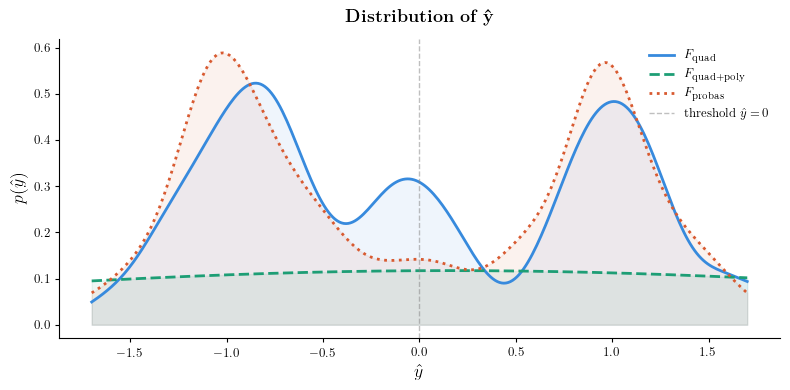

In [48]:
from scipy.stats import gaussian_kde
import numpy as np
import matplotlib.pyplot as plt
from zeroth.plot_losses import set_style

set_style()

fig, ax = plt.subplots(figsize=(8, 4))
mask = Y_test[:, 0] == 1
x = np.linspace(-1.7, 1.7, 300)

configs = [
    (Y_pred_quad[:, 0],      '#378ADD', '-',  r'$F_{\mathrm{quad}}$'),
    (Y_pred_quad_poly[:, 0], '#1D9E75', '--', r'$F_{\mathrm{quad+poly}}$'),
    (Y_pred_probas[:, 0],    '#D85A30', ':',  r'$F_{\mathrm{probas}}$'),
]

for data, color, ls, label in configs:
    kde = gaussian_kde(data, bw_method=0.15)
    ax.plot(x, kde(x), color=color, ls=ls, lw=2, label=label)
    ax.fill_between(x, kde(x), alpha=0.08, color=color)

ax.set_title(r"\textbf{Distribution of $\mathbf{\hat{y}}$}",
             fontsize=13, pad=12)
ax.axvline(threshold, color='gray', lw=1, ls='--', alpha=0.5,
           label=r'threshold $\hat{y}=0$')
ax.set_xlabel(r"$\hat{y}$", fontsize=13)
ax.set_ylabel(r"$p(\hat{y})$", fontsize=13)
ax.legend(frameon=False)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(f"figs/y_distribution_qrc.png", bbox_inches='tight', dpi=300)
plt.show()

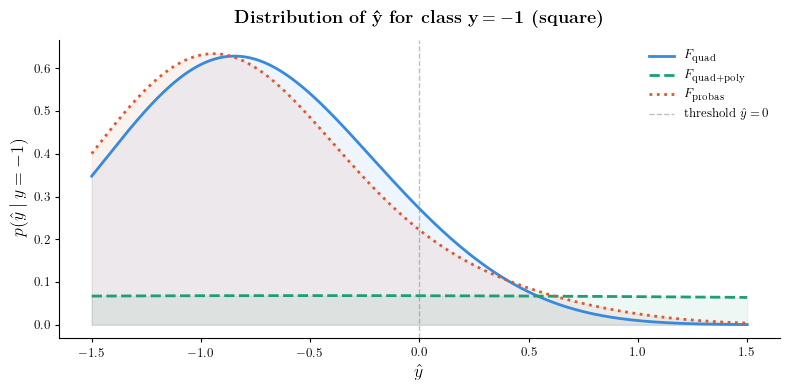

In [49]:
fig, ax = plt.subplots(figsize=(8, 4))
mask = Y_test[:, 0] == -1
x = np.linspace(-1.5, 1.5, 300)

configs = [
    (Y_pred_quad[mask, 0],      '#378ADD', '-',  r'$F_{\mathrm{quad}}$'),
    (Y_pred_quad_poly[mask, 0], '#1D9E75', '--', r'$F_{\mathrm{quad+poly}}$'),
    (Y_pred_probas[mask, 0],    '#D85A30', ':',  r'$F_{\mathrm{probas}}$'),
]

for data, color, ls, label in configs:
    kde = gaussian_kde(data, bw_method=1)
    ax.plot(x, kde(x), color=color, ls=ls, lw=2, label=label)
    ax.fill_between(x, kde(x), alpha=0.08, color=color)

ax.set_title(r"\textbf{Distribution of $\mathbf{\hat{y}}$ for class $\mathbf{y=-1}$ (square)}",
             fontsize=13, pad=12)
ax.axvline(threshold, color='gray', lw=1, ls='--', alpha=0.5,
           label=r'threshold $\hat{y}=0$')
ax.set_xlabel(r"$\hat{y}$", fontsize=13)
ax.set_ylabel(r"$p(\hat{y} \mid y=-1)$", fontsize=13)
ax.legend(frameon=False)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(f"figs/y_0_distribution_qrc.png", bbox_inches='tight', dpi=300)
plt.show()

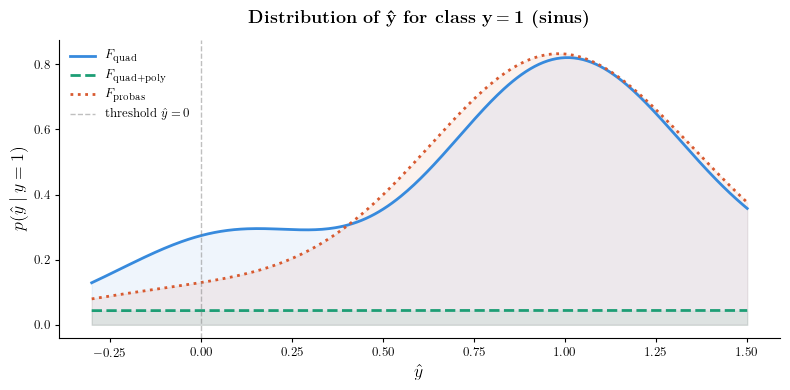

In [50]:
fig, ax = plt.subplots(figsize=(8, 4))
mask = Y_test[:, 0] == 1
x = np.linspace(-0.3, 1.5, 300)

configs = [
    (Y_pred_quad[mask, 0],      '#378ADD', '-',  r'$F_{\mathrm{quad}}$'),
    (Y_pred_quad_poly[mask, 0], '#1D9E75', '--', r'$F_{\mathrm{quad+poly}}$'),
    (Y_pred_probas[mask, 0],    '#D85A30', ':',  r'$F_{\mathrm{probas}}$'),
]

for data, color, ls, label in configs:
    kde = gaussian_kde(data)
    ax.plot(x, kde(x), color=color, ls=ls, lw=2, label=label)
    ax.fill_between(x, kde(x), alpha=0.08, color=color)

ax.set_title(r"\textbf{Distribution of $\mathbf{\hat{y}}$ for class $\mathbf{y=1}$ (sinus)}",
             fontsize=13, pad=12)
ax.axvline(threshold, color='gray', lw=1, ls='--', alpha=0.5,
           label=r'threshold $\hat{y}=0$')
ax.set_xlabel(r"$\hat{y}$", fontsize=13)
ax.set_ylabel(r"$p(\hat{y} \mid y=1)$", fontsize=13)
ax.legend(frameon=False)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(f"figs/y_1_distribution_qrc.png", bbox_inches='tight', dpi=300)
plt.show()

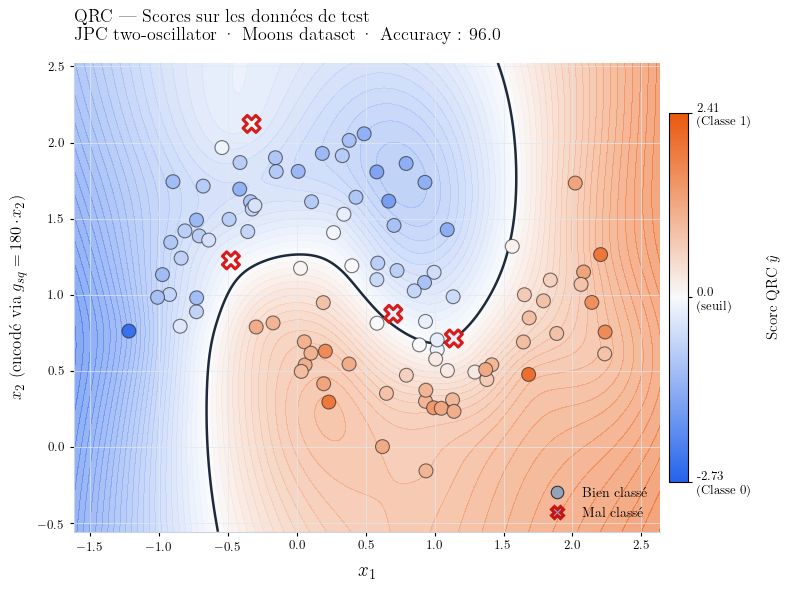

In [52]:
# ─────────────────────────────────────────────────────────────────────────────
# QRC — Visualisation sur les données de test (fond blanc + gradient RBF)
#
# Variables à brancher :
#   X_test      : shape (N, 2)
#   Y_test      : shape (N, 1) ou (N,)  — labels en {0,1} ou {-1,+1}
#   scores_test : shape (N, 1) ou (N,)  — score continu brut du readout
# ─────────────────────────────────────────────────────────────────────────────

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize, TwoSlopeNorm
from matplotlib.lines import Line2D
from scipy.interpolate import RBFInterpolator

# ── Mise à plat & normalisation des labels ───────────────────────────────────
x1 = X_test[:, 0].ravel()
x2 = X_test[:, 1].ravel()
y  = Y_test.ravel().astype(float)
s  = np.array(Y_pred_quad, dtype=float).ravel()

# Auto-détection du format de labels et du seuil de décision
if set(np.unique(y)) <= {-1., 1.}:
    threshold = 0.0
    y_bin = (y > 0).astype(int)
else:
    threshold = 0.0          # le readout QRC sort en ℝ centré sur 0
    y_bin = y.astype(int)

predicted = (s >= threshold).astype(int)
correct   = predicted == y_bin
wrong     = ~correct

# ── Gradient de fond par interpolation RBF ───────────────────────────────────
margin  = 0.4
x1g     = np.linspace(x1.min() - margin, x1.max() + margin, 300)
x2g     = np.linspace(x2.min() - margin, x2.max() + margin, 300)
xx1, xx2 = np.meshgrid(x1g, x2g)
grid    = np.c_[xx1.ravel(), xx2.ravel()]

rbf = RBFInterpolator(
    np.c_[x1, x2], s,
    kernel='thin_plate_spline', smoothing=0.5
)
Z = rbf(grid).reshape(xx1.shape)

# ── Palette (thème blanc) ─────────────────────────────────────────────────────
col0     = '#2563eb'   # bleu profond  → classe 0
col1     = '#ea580c'   # orange brûlé  → classe 1
col_mid  = '#f8fafc'   # blanc cassé   → zone de doute

cmap = LinearSegmentedColormap.from_list(
    'qrc_white',
    [(0.0, col0), (0.5, col_mid), (1.0, col1)],
    N=512
)

# Centrage de la colormap sur le seuil réel
z_min, z_max = float(Z.min()), float(Z.max())
vcenter = float(threshold)
vcenter = np.clip(vcenter, z_min + 1e-6, z_max - 1e-6)
norm_bg = TwoSlopeNorm(vmin=z_min, vcenter=vcenter, vmax=z_max)

# ── Figure ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6), facecolor='white')
ax.set_facecolor('white')

# Fond dégradé
ax.contourf(xx1, xx2, Z, levels=60, cmap=cmap, norm=norm_bg,
            alpha=0.55, zorder=1)

# Iso-contour au seuil de décision
ax.contour(xx1, xx2, Z, levels=[threshold],
           colors=['#1e293b'], linewidths=[1.8],
           linestyles=['-'], zorder=3)

# ── Points bien classés ───────────────────────────────────────────────────────
n_ok = int(correct.sum())
if n_ok > 0:
    ax.scatter(
        x1[correct], x2[correct],
        c=list(s[correct]),
        cmap=cmap, norm=norm_bg,
        s=100, linewidths=0.8,
        edgecolors=[(0.1, 0.1, 0.1, 0.6)] * n_ok,
        zorder=4,
    )

# ── Points mal classés ────────────────────────────────────────────────────────
n_ko = int(wrong.sum())
if n_ko > 0:
    ax.scatter(
        x1[wrong], x2[wrong],
        c=list(s[wrong]),
        cmap=cmap, norm=norm_bg,
        s=150, linewidths=2.2,
        edgecolors=[(0.85, 0.1, 0.1, 1.0)] * n_ko,
        zorder=5,
        marker='X',
    )

# ── Colorbar ──────────────────────────────────────────────────────────────────
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm_bg)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, fraction=0.03, pad=0.015)
cbar.set_label('Score QRC  $\\hat{y}$', fontsize=11, labelpad=10)
cbar.ax.tick_params(labelsize=9)
tick_vals = [z_min, threshold, z_max]
tick_lbls = [f'{z_min:.2f}\n(Classe 0)', f'{threshold:.1f}\n(seuil)',
             f'{z_max:.2f}\n(Classe 1)']
cbar.set_ticks(tick_vals)
cbar.set_ticklabels(tick_lbls)

# ── Axes & titre ──────────────────────────────────────────────────────────────
acc = float(correct.mean()) * 100
ax.set_xlabel('$x_1$', fontsize=14, labelpad=8)
ax.set_ylabel(
    '$x_2$  (encodé via $g_{sq} = 180 \\cdot x_2$)',
    fontsize=12, labelpad=8
)
ax.set_title(
    f'QRC — Scores sur les données de test\n'
    f'JPC two-oscillator  ·  Moons dataset  ·  Accuracy : {acc:.1f} %',
    fontsize=13, fontweight='bold', pad=16, loc='left'
)
ax.tick_params(labelsize=9)
for spine in ax.spines.values():
    spine.set_edgecolor('#cbd5e1')

# ── Légende ───────────────────────────────────────────────────────────────────
legend_elements = [
    Line2D([0], [0], marker='o', linestyle='None',
           markerfacecolor='#94a3b8', markersize=9,
           markeredgecolor='#333333', markeredgewidth=0.8,
           label='Bien classé'),
    Line2D([0], [0], marker='X', linestyle='None',
           markerfacecolor='#94a3b8', markersize=9,
           markeredgecolor='#cc1111', markeredgewidth=2.2,
           label='Mal classé'),
]
ax.legend(handles=legend_elements, loc='lower right',
          framealpha=0.85, fontsize=10)

ax.grid(True, color='#e2e8f0', linewidth=0.6, alpha=0.8, zorder=0)
plt.tight_layout()
plt.savefig('qrc_test_scatter.png', dpi=180, bbox_inches='tight',
            facecolor='white')
plt.show()